In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
from statsmodels.stats.multitest import multipletests

from utils.autocorrelation_per_state import autocorrelation_per_state # Import custom autoccorelation function

In [26]:
# Needed Columns for the Hypothesis testing
#data_needed = ["Order Date", "Category", "Revenue", "Shipping Address State", "tavg"]

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/grocery_data.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"])
groceries_df.set_index("Order Date", inplace=True)
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

## Base implementation of Granger Causation Matrix

In [27]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    maxlag = 12    
    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [28]:
# List of states
states_list = groceries_df["Shipping Address State"].unique()

# Creating Filtered dataframe for Granger test
df_granger_grocerie = groceries_df[["Revenue", "tavg", "Shipping Address State"]]

df_granger_fashion = fashion_df[["Revenue", "tavg", "Shipping Address State"]]


## Groceries Granger Test: First order diff for Revenue - Temp no seasonality

In [29]:
state_p_values_grocerie = {}
p_values_grocieries_list = []

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_grocerie[states_list[i]] = p_value
        p_values_grocieries_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


## Fashion Granger Test: First order diff for Revenue - Temp no seasonality

In [30]:
state_p_values_fashion = {}
p_values_fashion_list = []

for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state = df_one_state.iloc[365:, ]

        #Fist order Diff for Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
    
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values_fashion[states_list[i]] = p_value
        p_values_fashion_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


# Implementation of Multiple Error Adjustments via Holm-Bonferroni method

In [31]:
# 1. Order p-values largest -> smallest 
# 2. Compare against threshold 
# 2.2 Threshold: p(1) compare against alpha/n
        # p(2) compare alpha/n-1
# 3. Procedure stops at first non-significant results 


reject, adj_pvals = multipletests(p_values_grocieries_list, method='holm', is_sorted = False)[:2]
print("Groceries Category \n")
print(reject)
print("-------------")
print(adj_pvals)


reject, adj_pvals = multipletests(p_values_fashion_list, method='holm', is_sorted = False)[:2]
print("\n Fashion Category\n")
print(reject)
print("-------------")
print(adj_pvals)


Groceries Category 

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
  True False False False False False False False False False False False]
-------------
[1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
 1.     1.     1.     1.     1.     1.     1.     1.     0.0799 1.
 1.     1.     1.     0.3828 1.     1.     1.     1.     1.     1.
 1.     1.     1.     0.1755 1.     1.     0.0144 1.     1.     0.3828
 1.     1.     1.     1.     1.     0.0874 1.     1.    ]

 Fashion Category

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]
-------------
[1.     1.     

## Visualization Granger Test Groceries

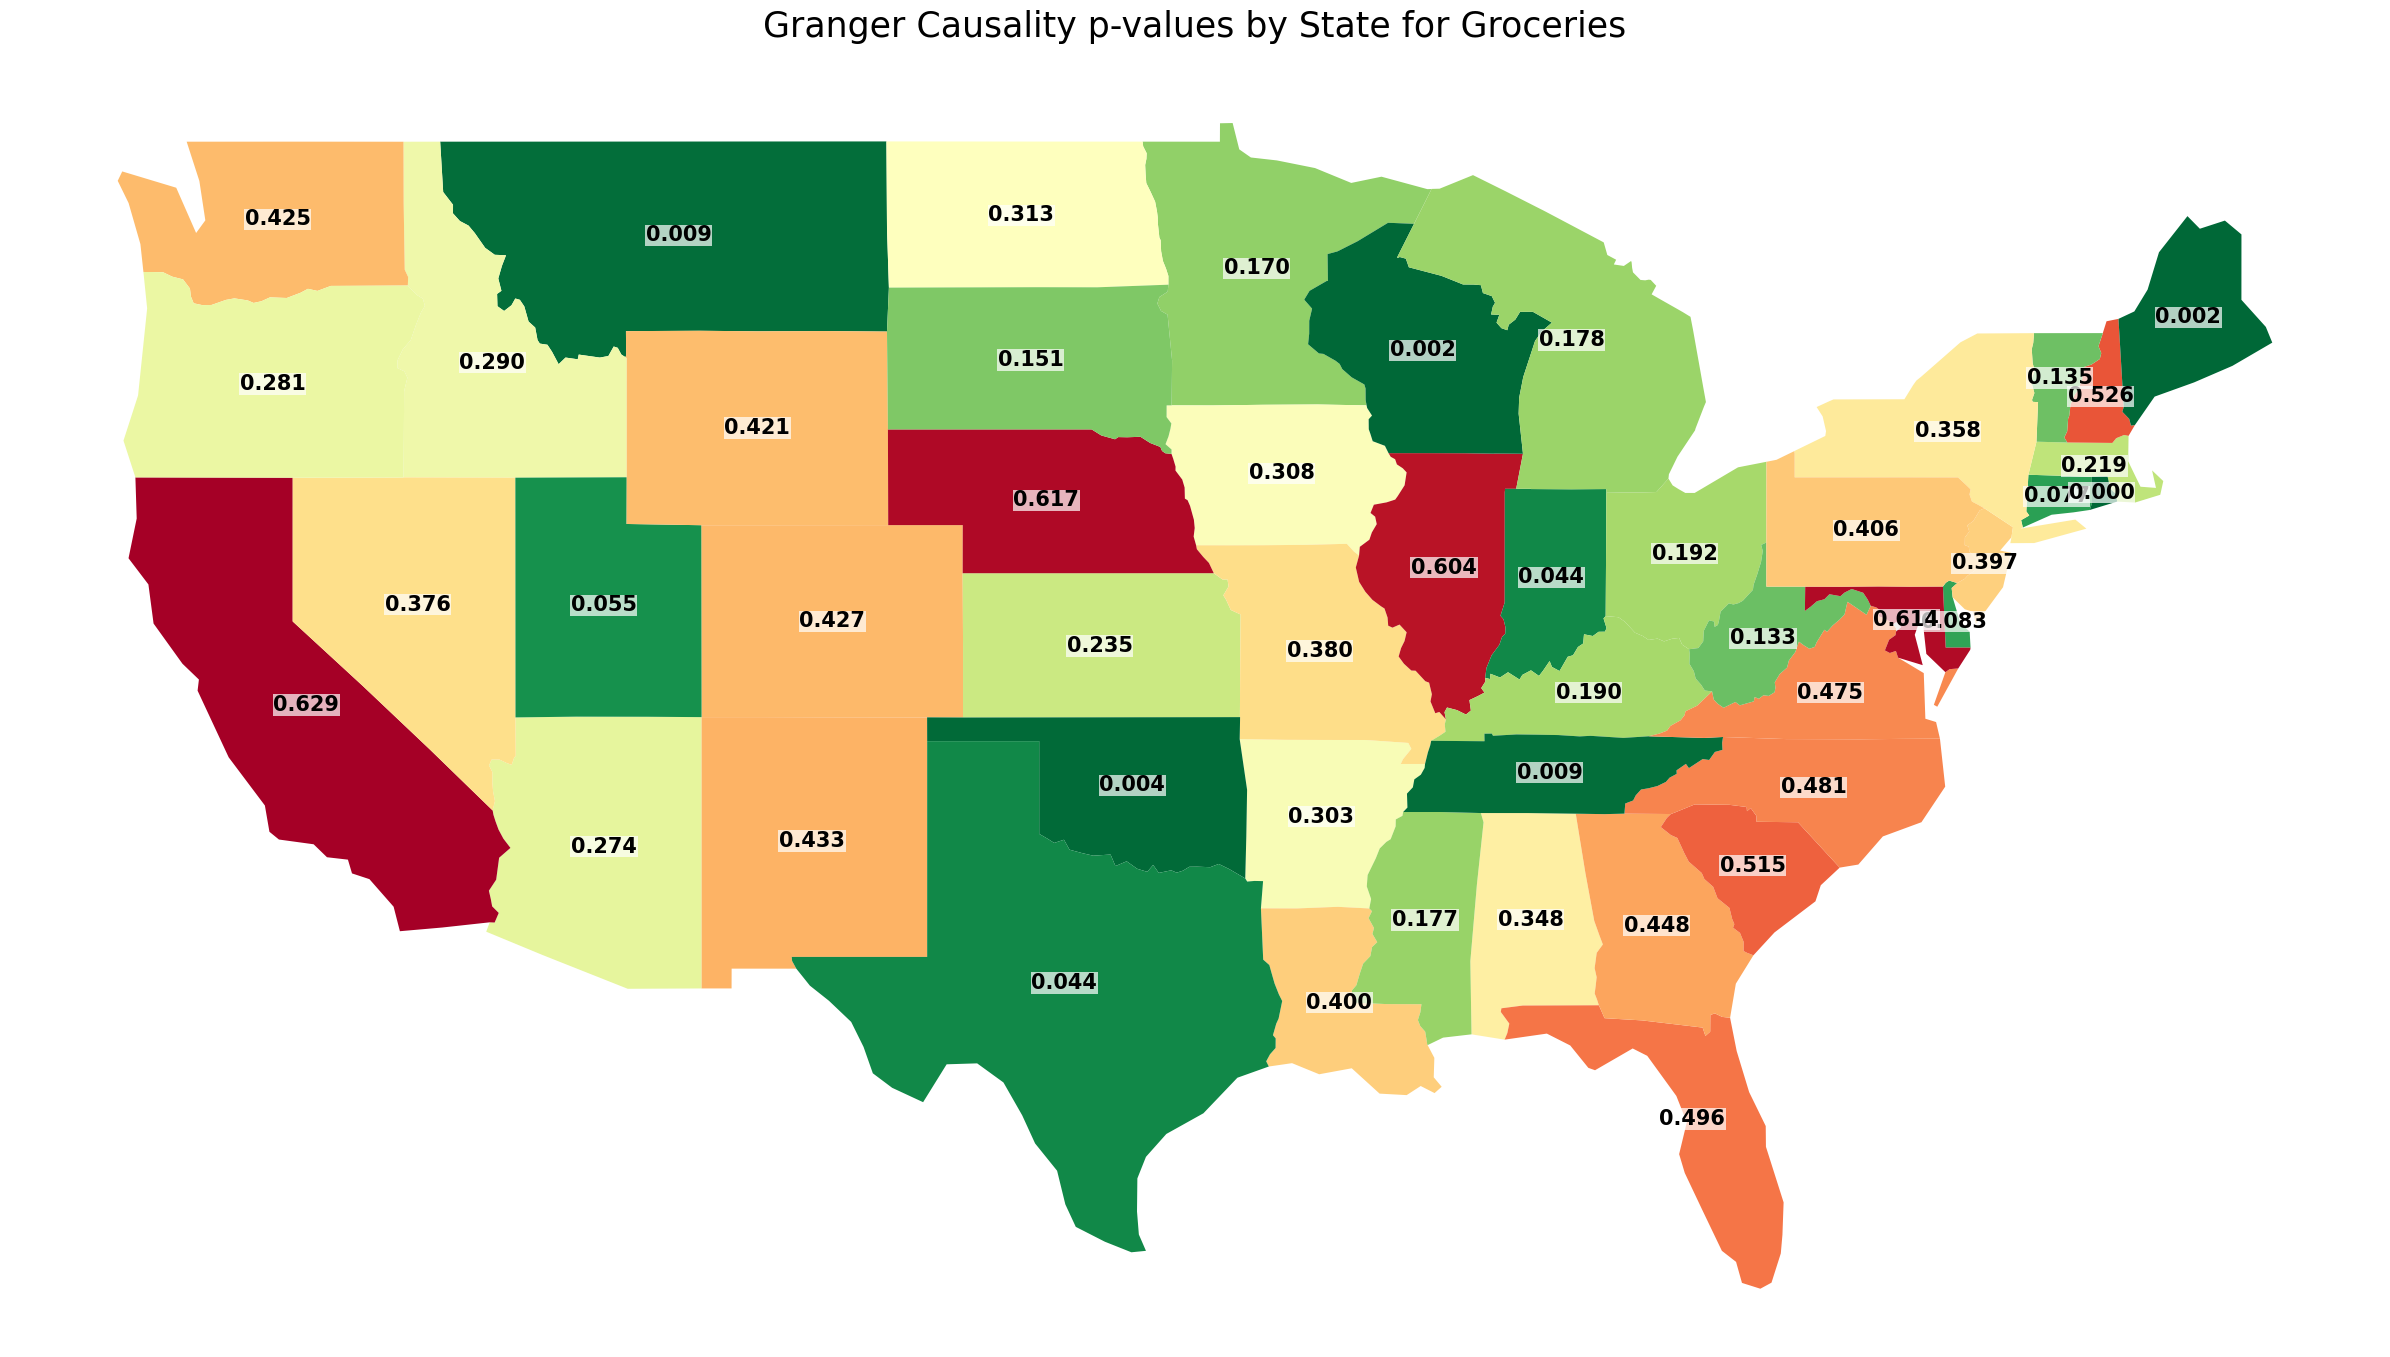

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'


usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  

usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.RdYlGn_r

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=15,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality p-values by State for Groceries', fontsize=25, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

## Visualization Granger Test Fashion

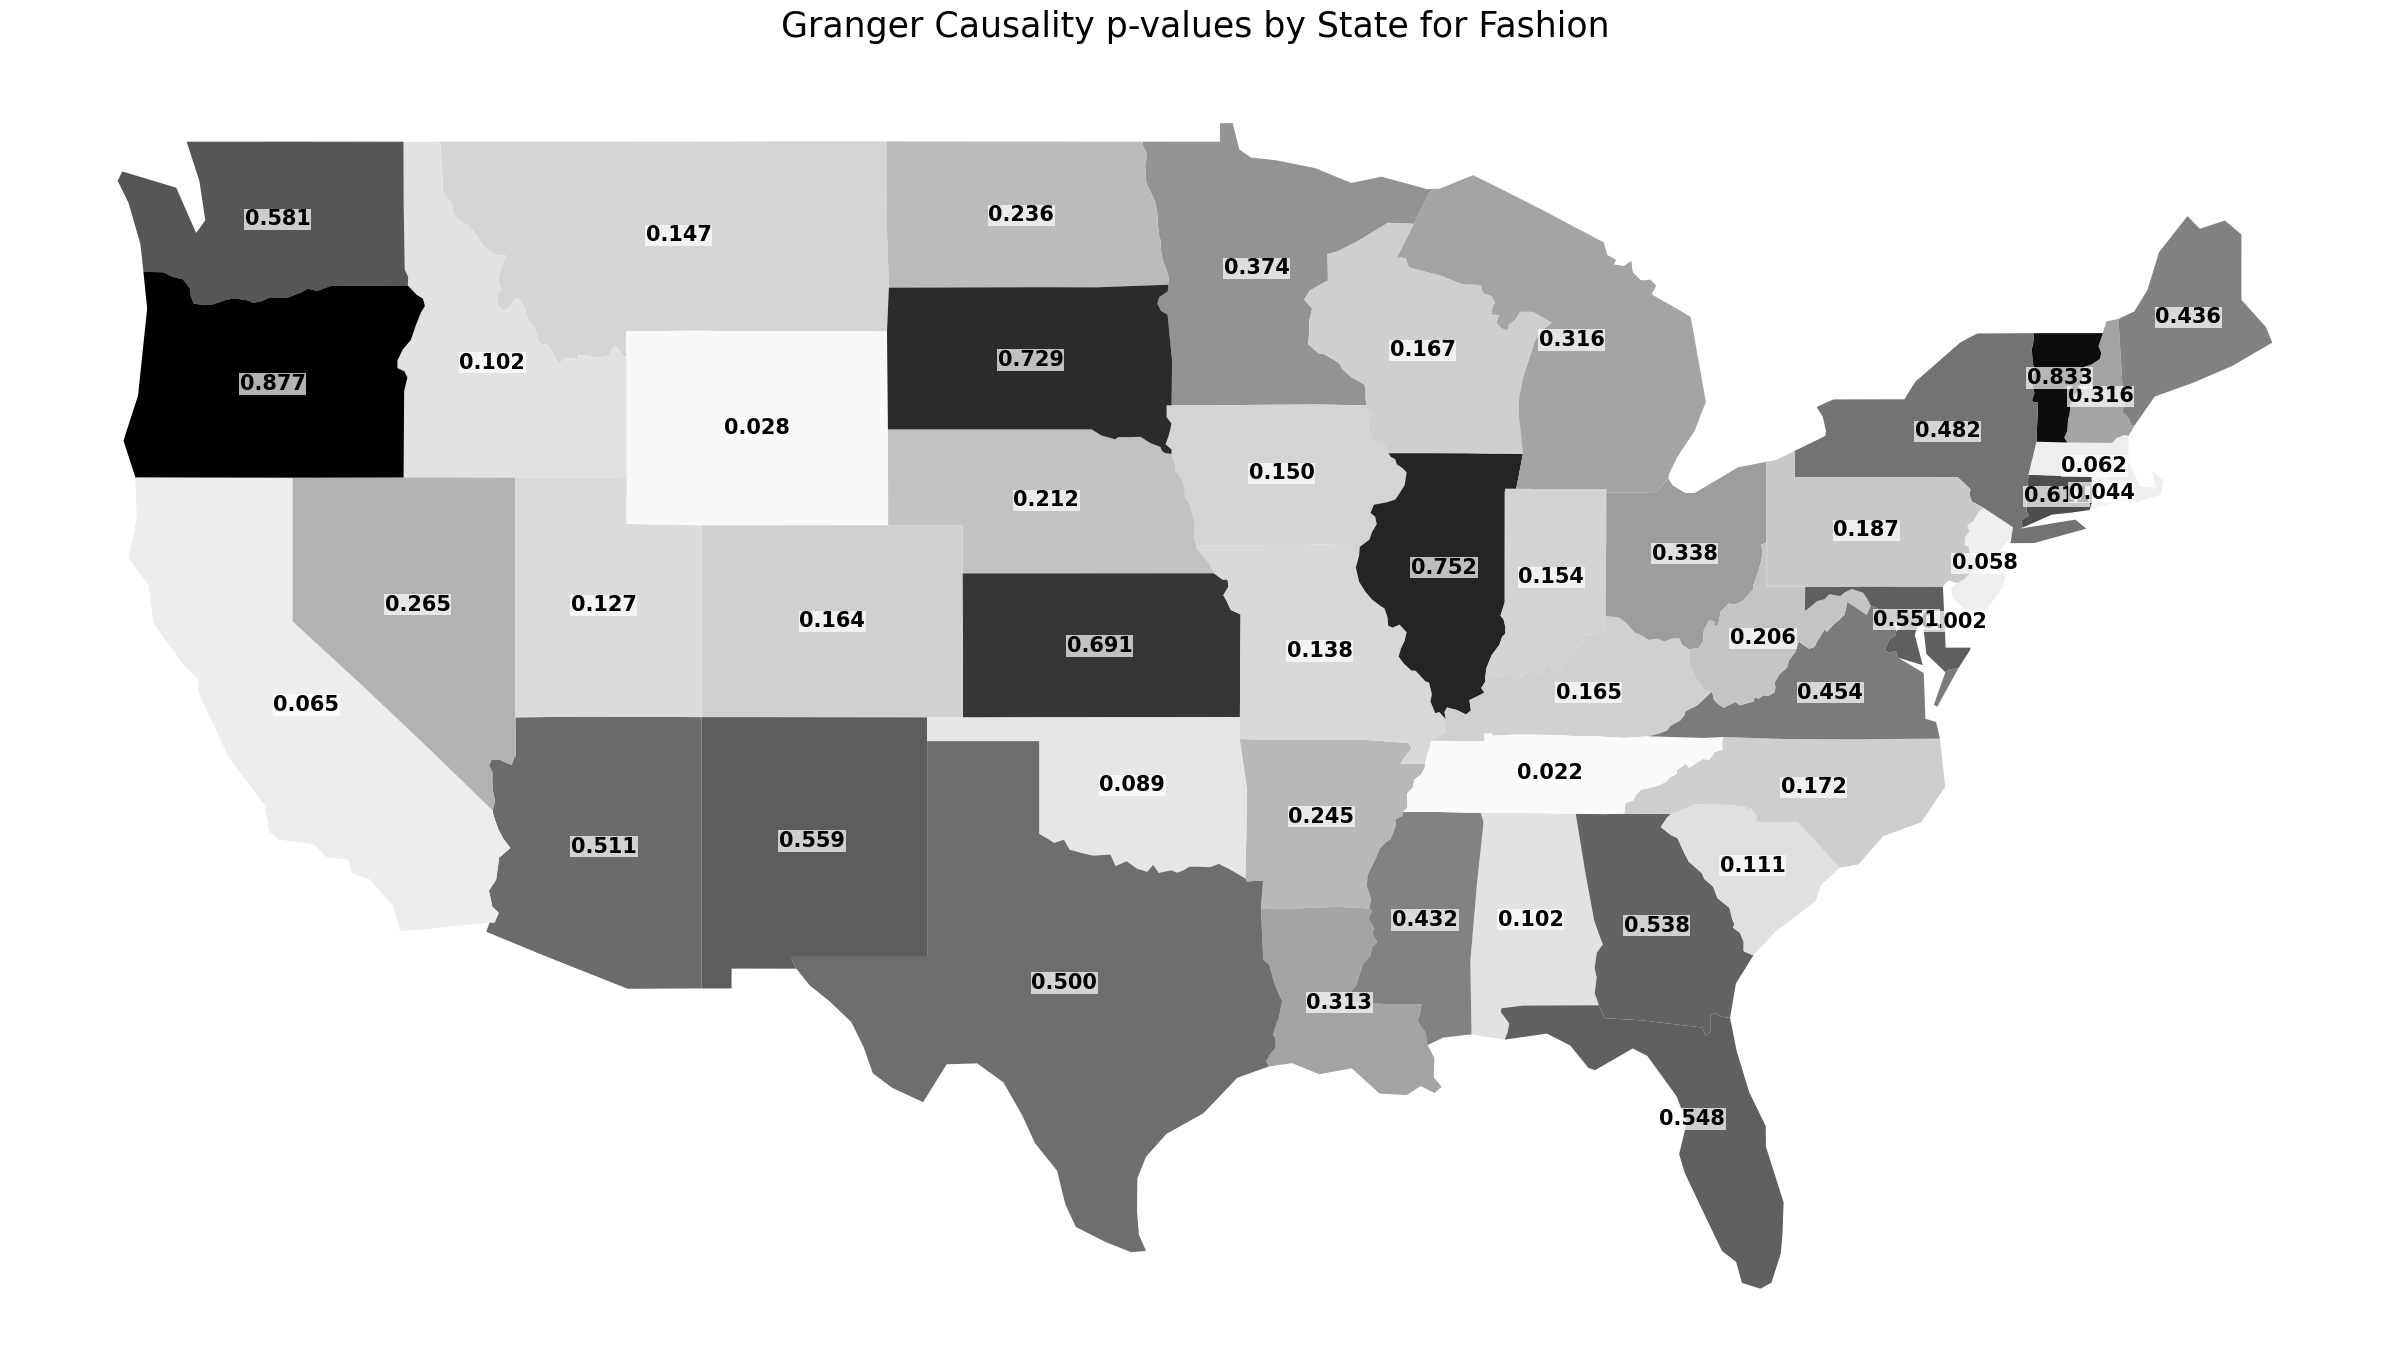

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_fashion, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile - CORRECTED URL
# Replace the read_file line with:
usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  # Updated from 'STUSPS' to 'postal' which is the correct column name in current Natural Earth Data

# Rest of your code remains the same
usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.binary

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=15,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality p-values by State for Fashion', fontsize=25, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Autocorrelation for first order Revenue lags

### Approach 1 (old)

In [34]:
for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

C:\Users\morit\AppData\Local\Temp\ipykernel_11620\3034542748.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])


In [35]:
series = df_one_state["first_order_diff_Revenue"]

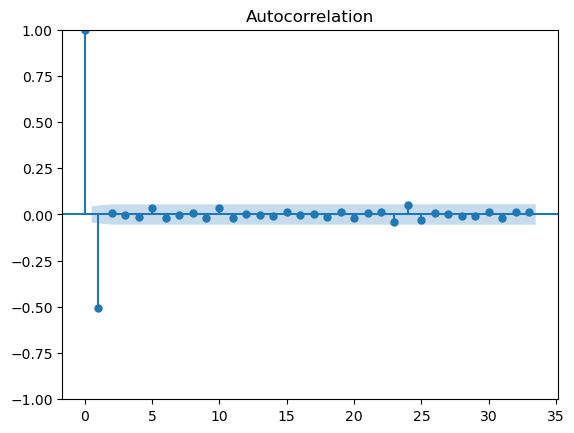

In [36]:
plot_acf(series)
plt.show()

#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/

Shows that if there was a purchase on t=0 it is less likley that someone is purchasing at t=1. Makes sense since when you bought something you are unlikley to buy something imeadiatly the next day. 

### Approach 2 (old)

In [37]:
import pandas as pd

# Take df of 
#1 subset 
#2 order 
#3 first order diff 
#4 Autocorrelation 


def autocorrelation_per_state(data): 
    states_list = data["Shipping Address State"].unique()
    results_df = pd.DataFrame(columns=['State', 't', 't+1','t+2','t+3','t+4','t+5','t+6'])

    for state in states_list: 
        # Filter for only one State
        state_filter = data["Shipping Address State"] == state # Create subset for only one state
        df_one_state = data[state_filter]

        # Order datapoints by date 
        df_one_state = df_one_state.sort_values("Order Date", ascending=True)

        # Calculate first order diff
        first_order_diff = [0]
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])
        
        df_one_state["first_order_diff_Revenue"] = first_order_diff

        # Calculate autocorrelation
        series = df_one_state["first_order_diff_Revenue"]

        # using shift function to shift the values.
        dataframe = pd.concat([series.shift(6), series.shift(5), series.shift(4), series.shift(3), series.shift(2), series.shift(1), series], axis=1)
        # naming the columns
        dataframe.columns = ['t', 't+1', 't+2', 't+3', 't+4', 't+5', 't+6']

        # using corr() function to compute the correlation
        result = dataframe.corr()
        new_row = {"State": state, "t": result.iloc[0,0], "t+1": result.iloc[0,1], "t+2": result.iloc[0,2], "t+3": result.iloc[0,3], "t+4": result.iloc[0,4], "t+5": result.iloc[0,5], "t+6": result.iloc[0,6]}
        results_df.loc[len(results_df)] = new_row

    return results_df

### Approach 3 (New)

Text(0.5, 1.0, 'ACF by State')

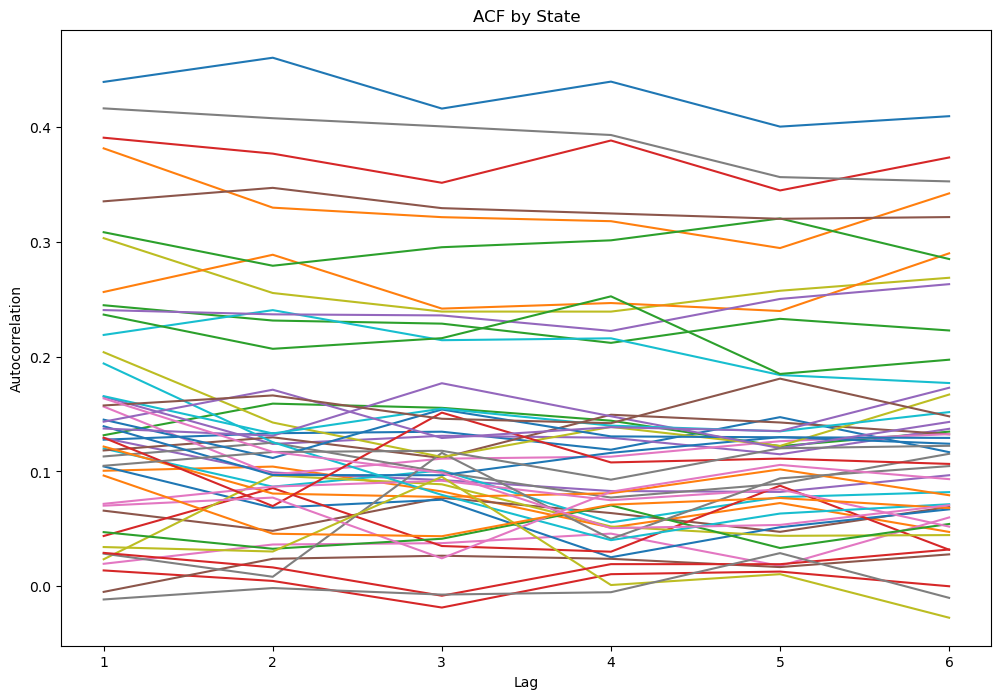

In [38]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_results = {}

for state in states_list: 
    state_filter = fashion_df["Shipping Address State"] == state # Create subset for only one state
    df_one_state = fashion_df[state_filter]
    acf_values = acf(df_one_state["Revenue"], nlags=6)
    acf_results[state] = acf_values

# Create a plot
plt.figure(figsize=(12, 8))

# Plot ACF for each state
for state, acf_values in acf_results.items():
    plt.plot(range(1, len(acf_values)), acf_values[1:], label=state)

plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('ACF by State')

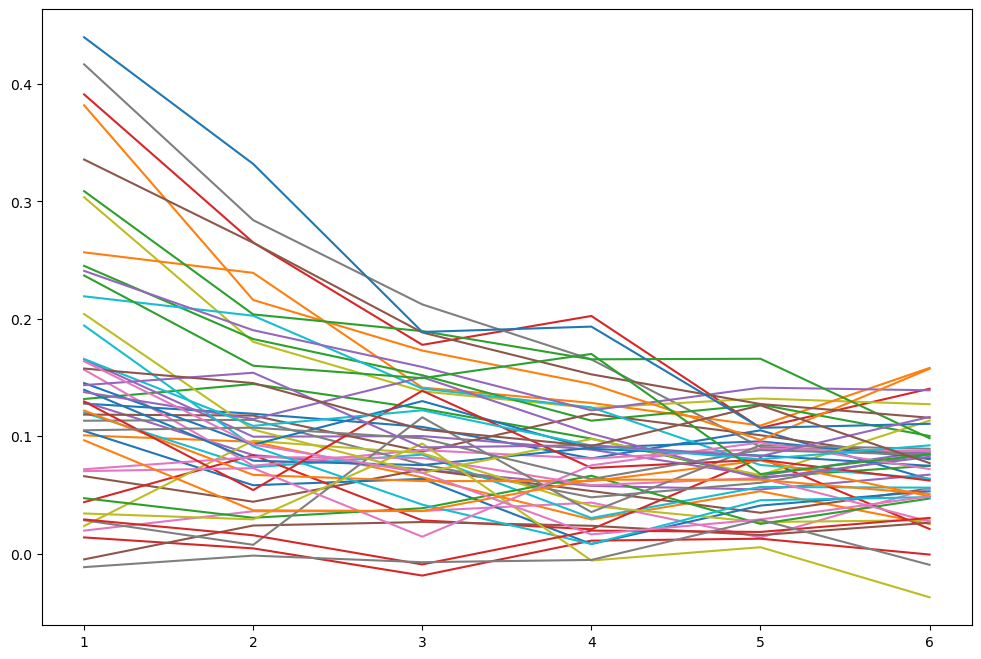

In [39]:
pacf_results = {}

for state in states_list: 
    state_filter = fashion_df["Shipping Address State"] == state # Create subset for only one state
    df_one_state = fashion_df[state_filter]
    pacf_values = pacf(df_one_state["Revenue"], nlags=6)
    pacf_results[state] = pacf_values

# Create a plot
plt.figure(figsize=(12, 8))

# Plot ACF for each state
for state, pacf_values in pacf_results.items():
    plt.plot(range(1, len(pacf_values)), pacf_values[1:], label=state)

## Calculating the Autocorrleation using a combined revnue
When we split the revenue per state we get a lot of different results per state for the corrleation between the days. The assumption is that this is due to a lack of datadensity on a state level, leading to a lot of 0 values, which ultimatly influence our correlation resutls. 

Because of that we combine all the Fashion category revenue sources per day. This approach should allow us to achive the necessary datadensity needed to calculate an meaningfull autoccorlation between the days.

In [40]:
# Fashion combined
data = fashion_df.sort_values("Order Date", ascending=True)

fashion_df_combined = data.groupby(["Order Date"]).agg({"Revenue": "sum"})


fashion_df_combined["Revenue"] = fashion_df_combined["Revenue"].round(2)

fashion_df_combined.reset_index("Order Date", inplace=True)

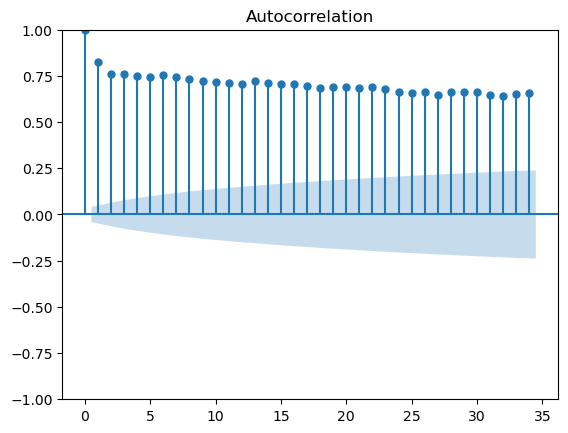

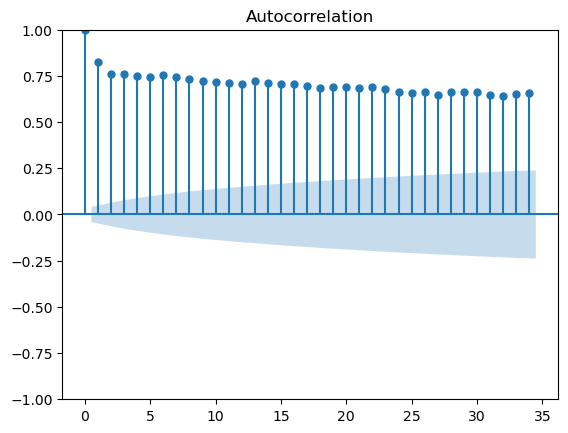

In [41]:
acf_values = acf(fashion_df_combined["Revenue"])

plot_acf(fashion_df_combined["Revenue"])
#plt.plot(range(1, len(acf_values)), acf_values[1:])

c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


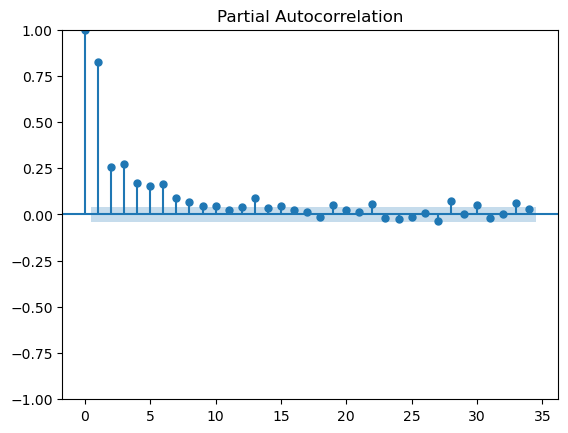

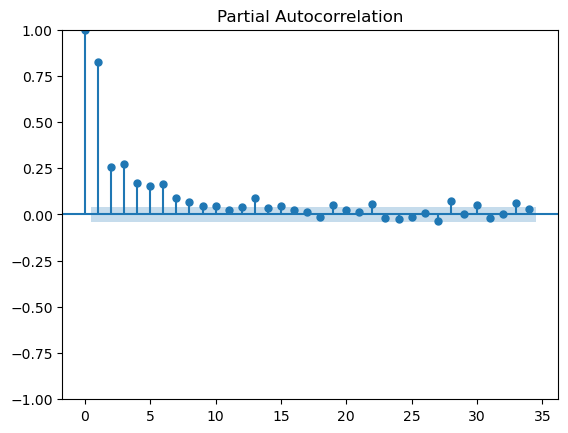

In [42]:
pacf_values = pacf(fashion_df_combined["Revenue"])
plot_pacf(fashion_df_combined["Revenue"])

#plt.plot(range(1, len(pacf_values)), pacf_values[1:])

### Fashion

In [43]:
#from utils.autocorrelation_per_state import autocorrelation_per_state

correlation_df = autocorrelation_per_state(fashion_df)
correlation_df.set_index('State', inplace=True)
correlation_df.head()

,t,t+1,t+2,t+3,t+4,t+5,t+6
State,,,,,,,
AL,1.0,-0.503654,0.002827,0.009869,-0.025171,0.033582,-0.031790
AR,1.0,-0.502067,0.014063,0.005458,-0.029363,0.025862,-0.045893
AZ,1.0,-0.515986,0.017966,0.004349,0.006319,-0.020023,0.005826
CA,1.0,-0.489015,0.009465,-0.051122,0.066014,-0.059265,0.026052
CO,1.0,-0.482796,-0.013490,0.001836,-0.005166,-0.008826,-0.006984


Text(95.72222222222221, 0.5, 'State')

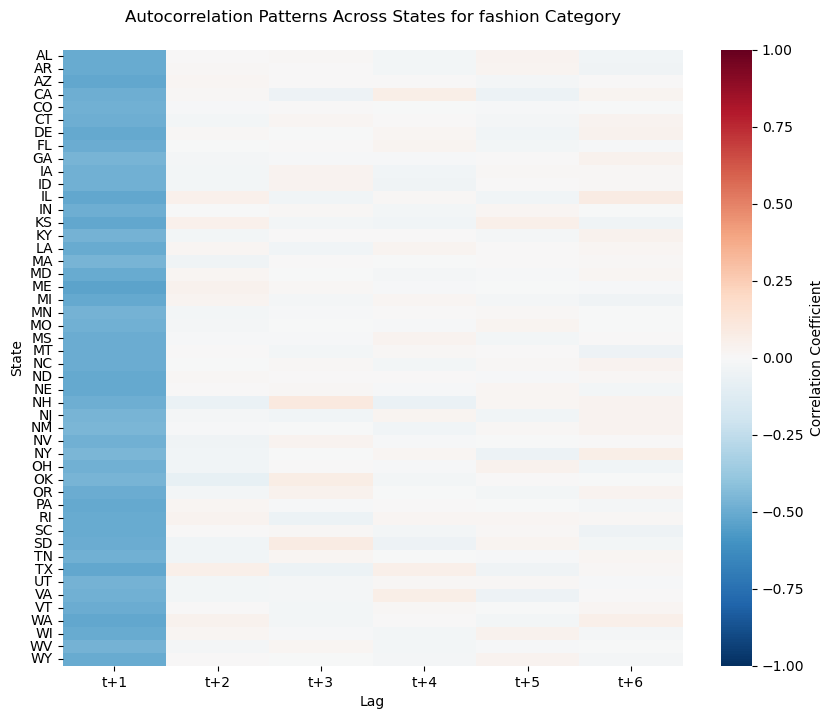

In [44]:
df_heatmap = correlation_df.iloc[:,1:] 

figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for fashion Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')

Basically there is only siginificant correlation between t and t+1

### Groceries

In [45]:
correlation_df = autocorrelation_per_state(groceries_df)
correlation_df.set_index('State', inplace=True)

Text(95.72222222222221, 0.5, 'State')

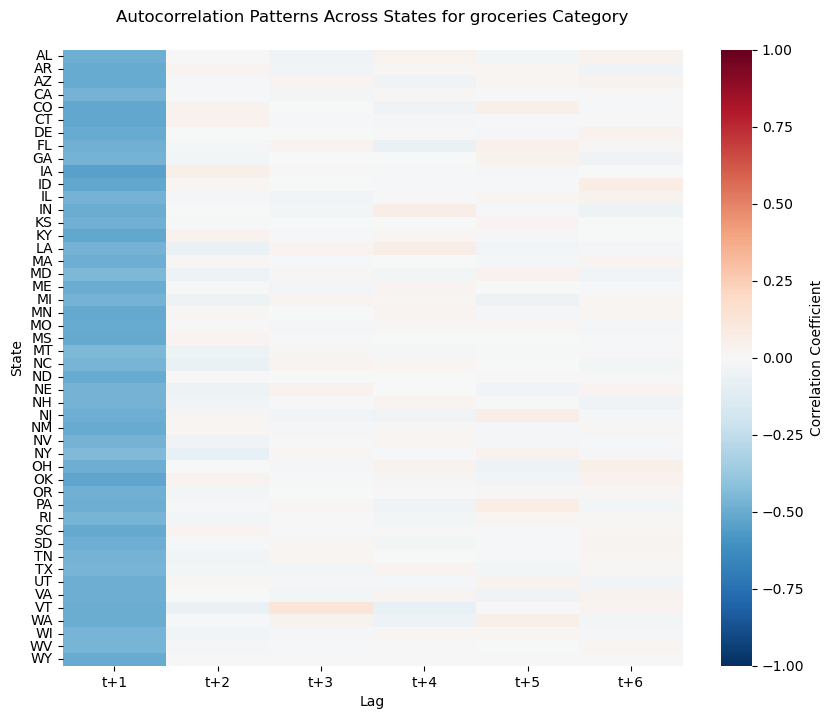

In [46]:
df_heatmap = correlation_df.iloc[:,1:] 
figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for groceries Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')

# Testing with granger causality
We could also included the granger test for Temp_No_Season -> Revenue as it seems to be performing quite good

In [47]:
state_p_values_grocerie = {}

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue", "Temp_No_Season"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_grocerie[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state AL temperature as a predictor has a p-value of: 0.3658
For the state AR temperature as a predictor has a p-value of: 0.2873
For the state AZ temperature as a predictor has a p-value of: 0.2293
For the state CA temperature as a predictor has a p-value of: 0.1632
For the state CO temperature as a predictor has a p-value of: 0.3293
For the state CT temperature as a predictor has a p-value of: 0.2042
For the state DE temperature as a predictor has a p-value of: 0.0227
For the state FL temperature as a predictor has a p-value of: 0.7153
For the state GA temperature as a predictor has a p-value of: 0.2872
For the state IA temperature as a predictor has a p-value of: 0.1723
For the state ID temperature as a predictor has a p-value of: 0.2687
For the state IL temperature as a predictor has a p-value of: 0.683
For the state IN temperature as a predictor has a p-value of: 0.0477
For the state KS temperature as a predictor has a p-value of: 0.2379
For the state KY temperature as a p

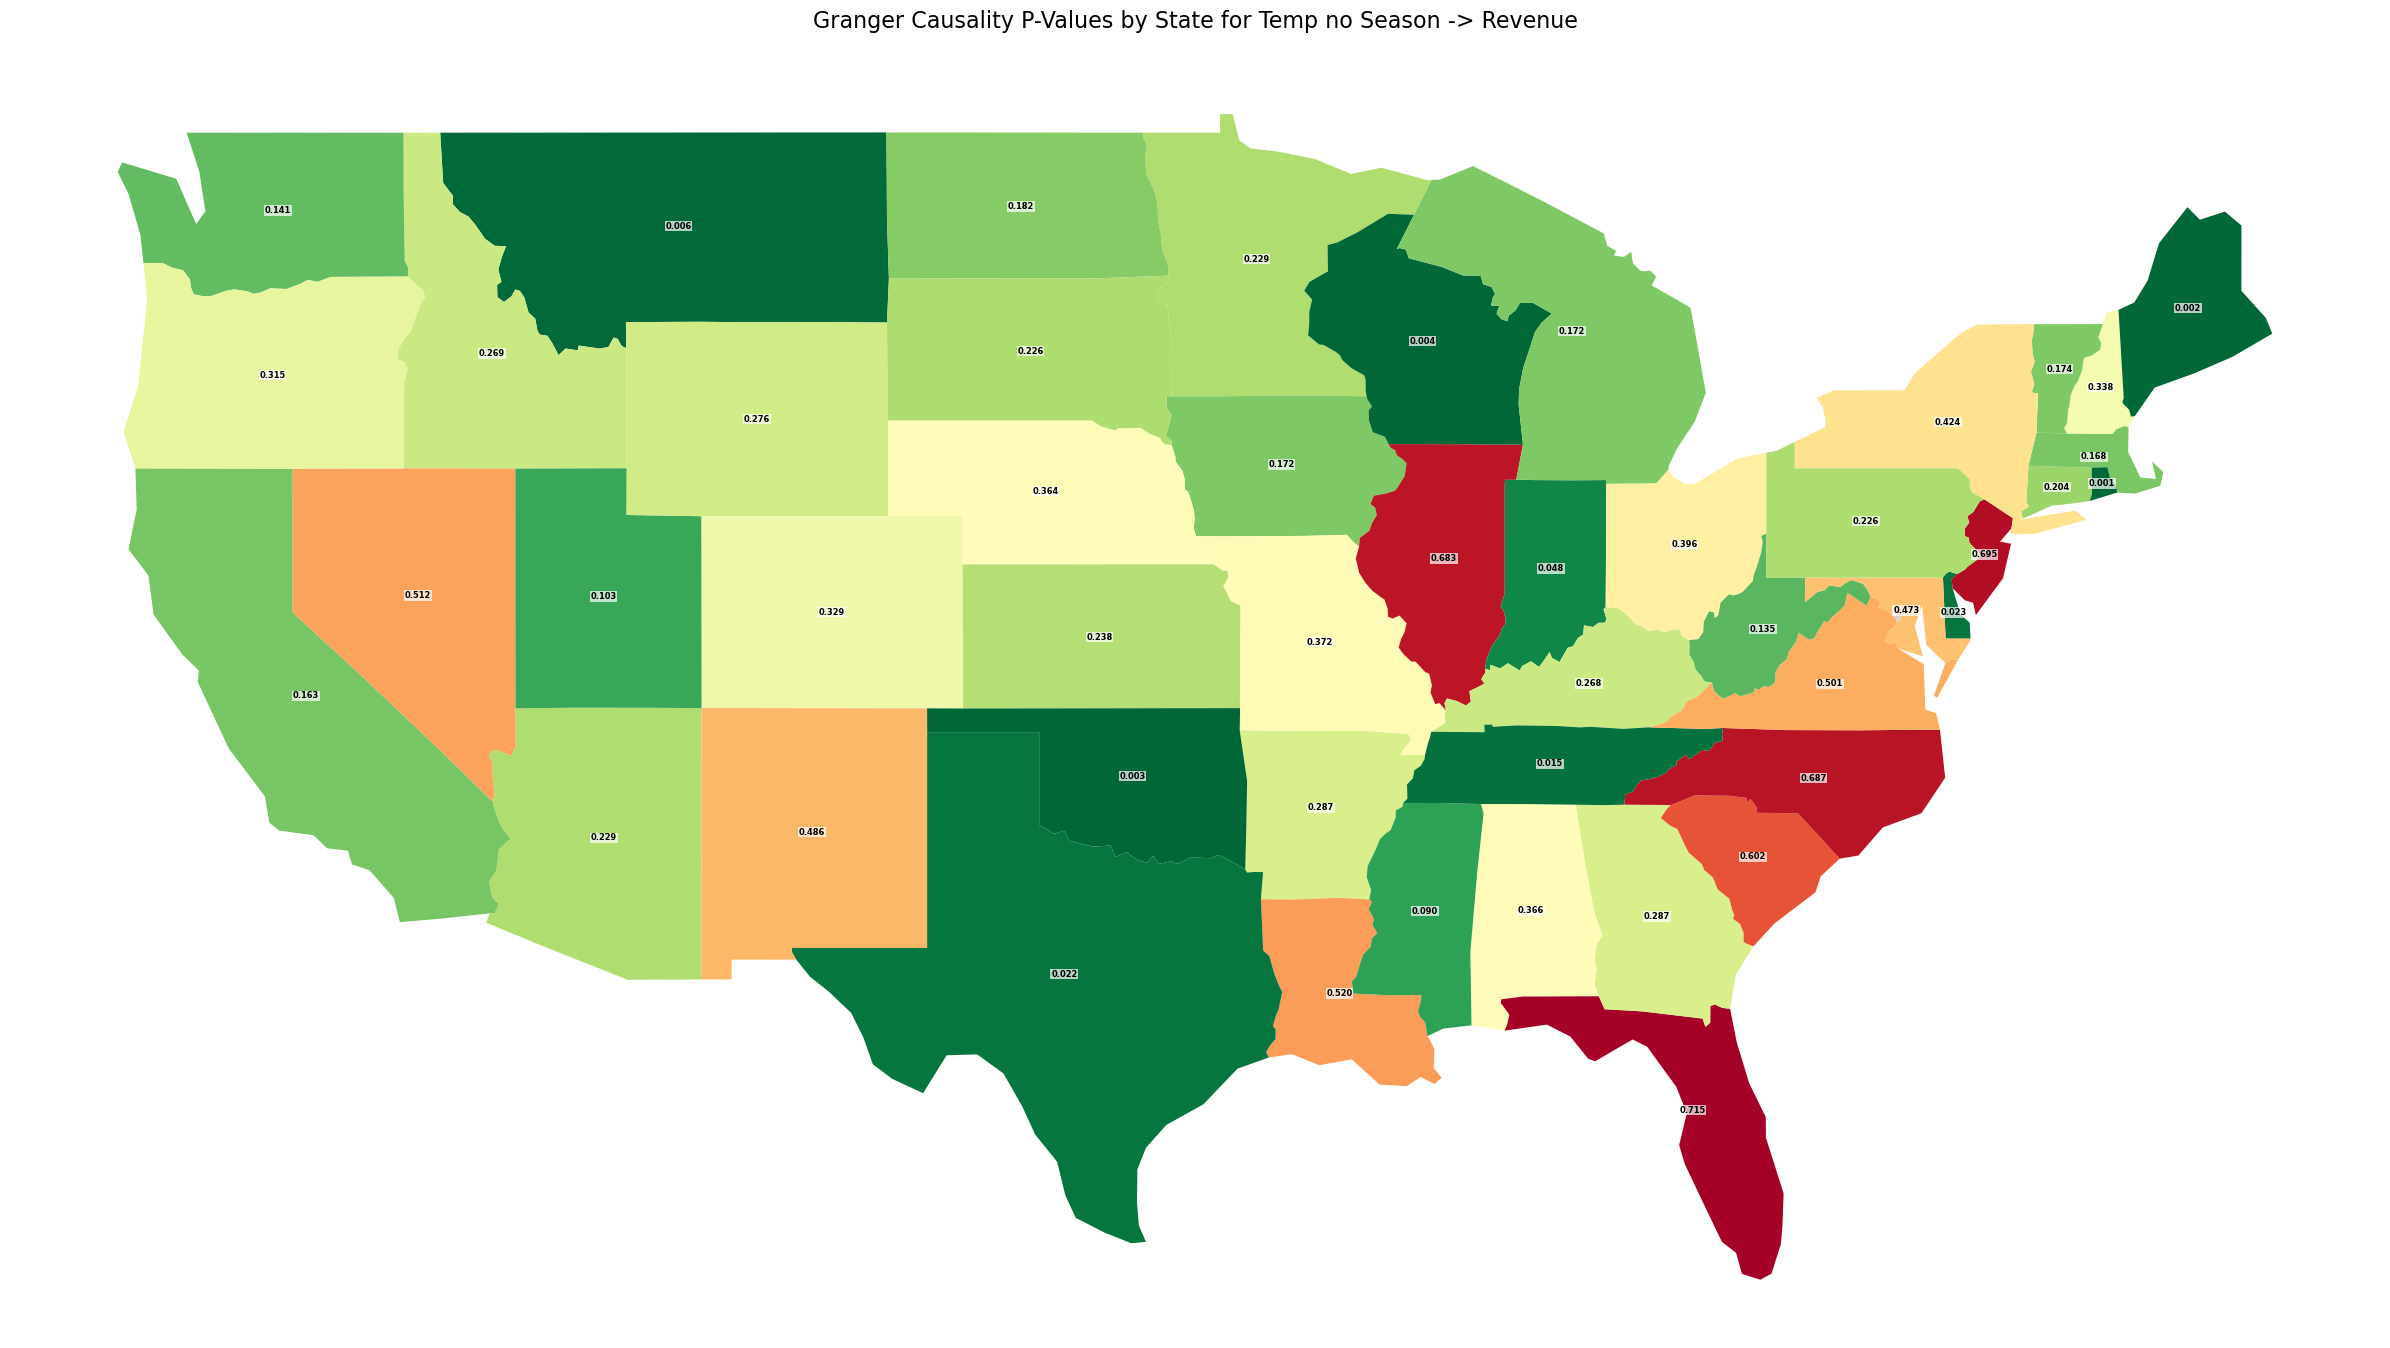

In [48]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile - CORRECTED URL
# Replace the read_file line with:
usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  # Updated from 'STUSPS' to 'postal' which is the correct column name in current Natural Earth Data

# Rest of your code remains the same
usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.RdYlGn_r

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality P-Values by State for Temp no Season -> Revenue', fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()